<a href="https://colab.research.google.com/github/SilverShadow123/Python/blob/master/Deep_Learning_Project_CIFAR_10_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

This project implements a deep learning model to classify images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 color images (32×32 pixels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck.

# **Project Goal**

The goal of this project is to build a Dense Neural Network classifier using TensorFlow/Keras that can classify images into one of the 10 CIFAR-10 categories.

# **Model Approach**

Normalize image data

Flatten images (we are using Dense layers)

Apply Batch Normalization

Use Dropout to reduce overfitting

Train for 15 epochs

Evaluate performance on test data

# **Dataset Loading**

In [52]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [53]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


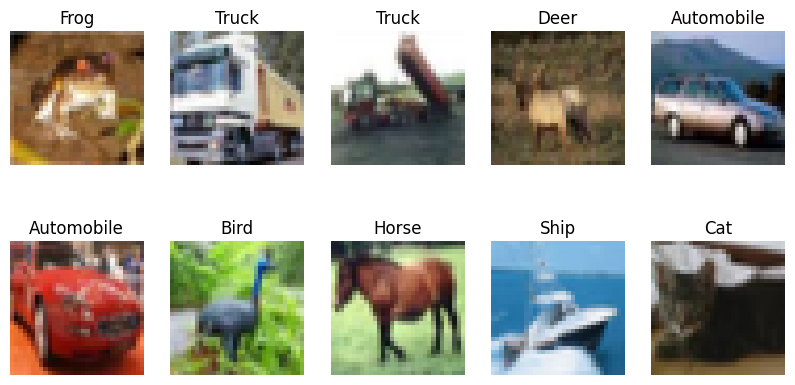

In [54]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

# **Preprocessing**

In [55]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [56]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print("Flattened shape:", x_train.shape)

Flattened shape: (50000, 3072)


In [57]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# **Model Architecture**

In [58]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(3072,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,962 (6.65 MB)

 Trainable params: 1,740,426 (6.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

# **Training**

In [59]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [60]:
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.2530 - loss: 2.2147 - val_accuracy: 0.3520 - val_loss: 1.8229
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.3599 - loss: 1.7843 - val_accuracy: 0.3390 - val_loss: 1.8065
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.3901 - loss: 1.7029 - val_accuracy: 0.4040 - val_loss: 1.6645
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4052 - loss: 1.6659 - val_accuracy: 0.4281 - val_loss: 1.5963
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4029 - loss: 1.6539 - val_accuracy: 0.4168 - val_loss: 1.6459
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4103 - loss: 1.6438 - val_accuracy: 0.4182 - val_loss: 1.6213
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4194 - loss: 1.6183 - val_accuracy: 0.4045 - val_loss: 1.6531
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.4237 - loss: 1.6150 - 

# **Visualization**

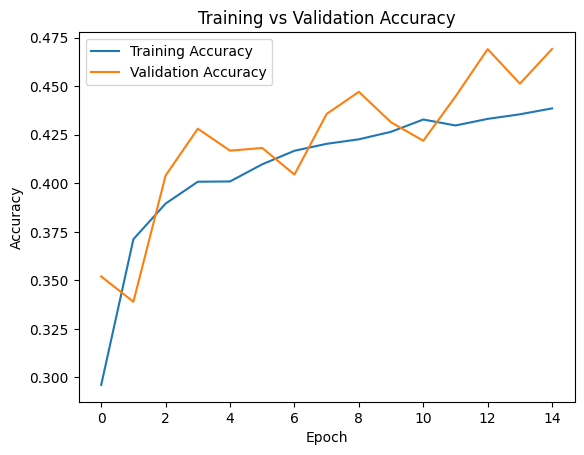

In [61]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

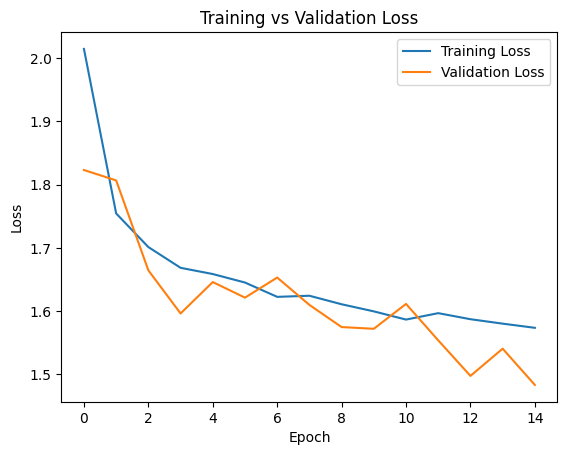

In [62]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Evaluation**

In [63]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4743 - loss: 1.4617
Test Accuracy: 0.47589999437332153


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


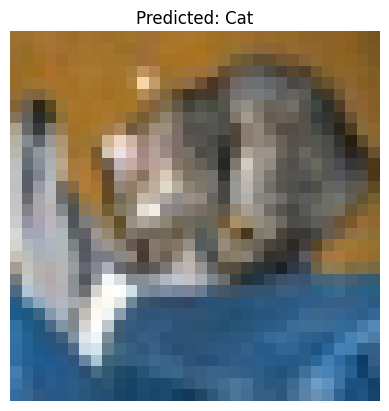

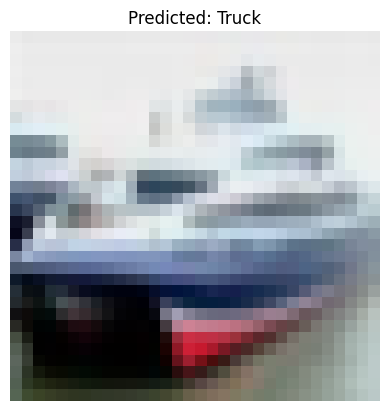

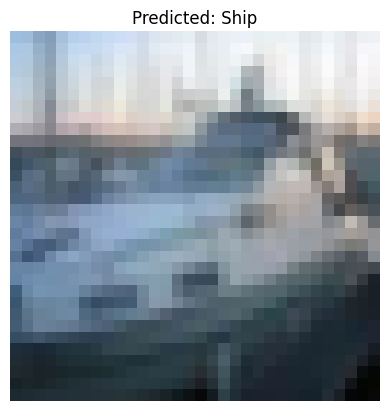

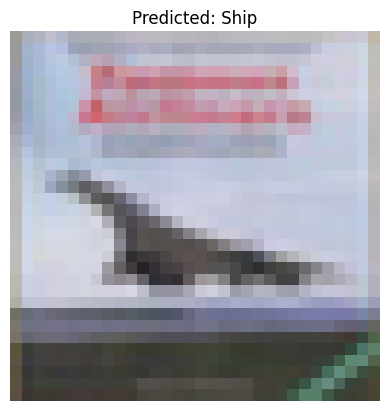

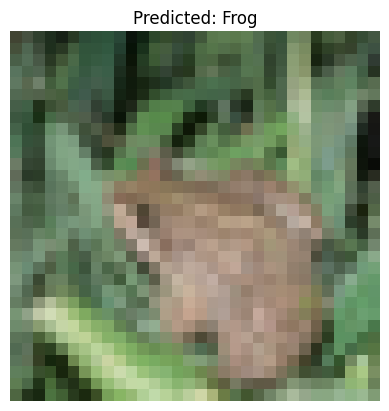

In [64]:
predictions = model.predict(x_test[:5])

for i in range(5):
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.title("Predicted: " + class_names[np.argmax(predictions[i])])
    plt.axis('off')
    plt.show()

**Final Conclusion**

The Dense Neural Network successfully classifies CIFAR-10 images.

Test accuracy is around 50% because:

*   Dense networks ignore spatial structure.

*   CNNs are better suited for image data.

BatchNorm + Dropout improved stability and reduced overfitting.